<a href="https://colab.research.google.com/github/penkebharathi18/BharathiPenke/blob/main/project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd


In [2]:
import os
os.listdir('/content')


['.config', 'Uber-Jan-Feb-FOIL.csv', 'sample_data']

In [3]:
import pandas as pd

data = pd.read_csv('/content/Uber-Jan-Feb-FOIL.csv')
data.head()


,dispatching_base_number,date,active_vehicles,trips
0,B02512,1/1/2015,190,1132
1,B02765,1/1/2015,225,1765
2,B02764,1/1/2015,3427,29421
3,B02682,1/1/2015,945,7679
4,B02617,1/1/2015,1228,9537


In [4]:
data.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 354 entries, 0 to 353
Data columns (total 4 columns):
 #   Column                   Non-Null Count  Dtype 
---  ------                   --------------  ----- 
 0   dispatching_base_number  354 non-null    object
 1   date                     354 non-null    object
 2   active_vehicles          354 non-null    int64 
 3   trips                    354 non-null    int64 
dtypes: int64(2), object(2)
memory usage: 11.2+ KB


In [5]:
data['date'] = pd.to_datetime(data['date'])


In [6]:
data.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 354 entries, 0 to 353
Data columns (total 4 columns):
 #   Column                   Non-Null Count  Dtype         
---  ------                   --------------  -----         
 0   dispatching_base_number  354 non-null    object        
 1   date                     354 non-null    datetime64[ns]
 2   active_vehicles          354 non-null    int64         
 3   trips                    354 non-null    int64         
dtypes: datetime64[ns](1), int64(2), object(1)
memory usage: 11.2+ KB


In [7]:
data['Day'] = data['date'].dt.day
data['Month'] = data['date'].dt.month
data['DayOfWeek'] = data['date'].dt.dayofweek


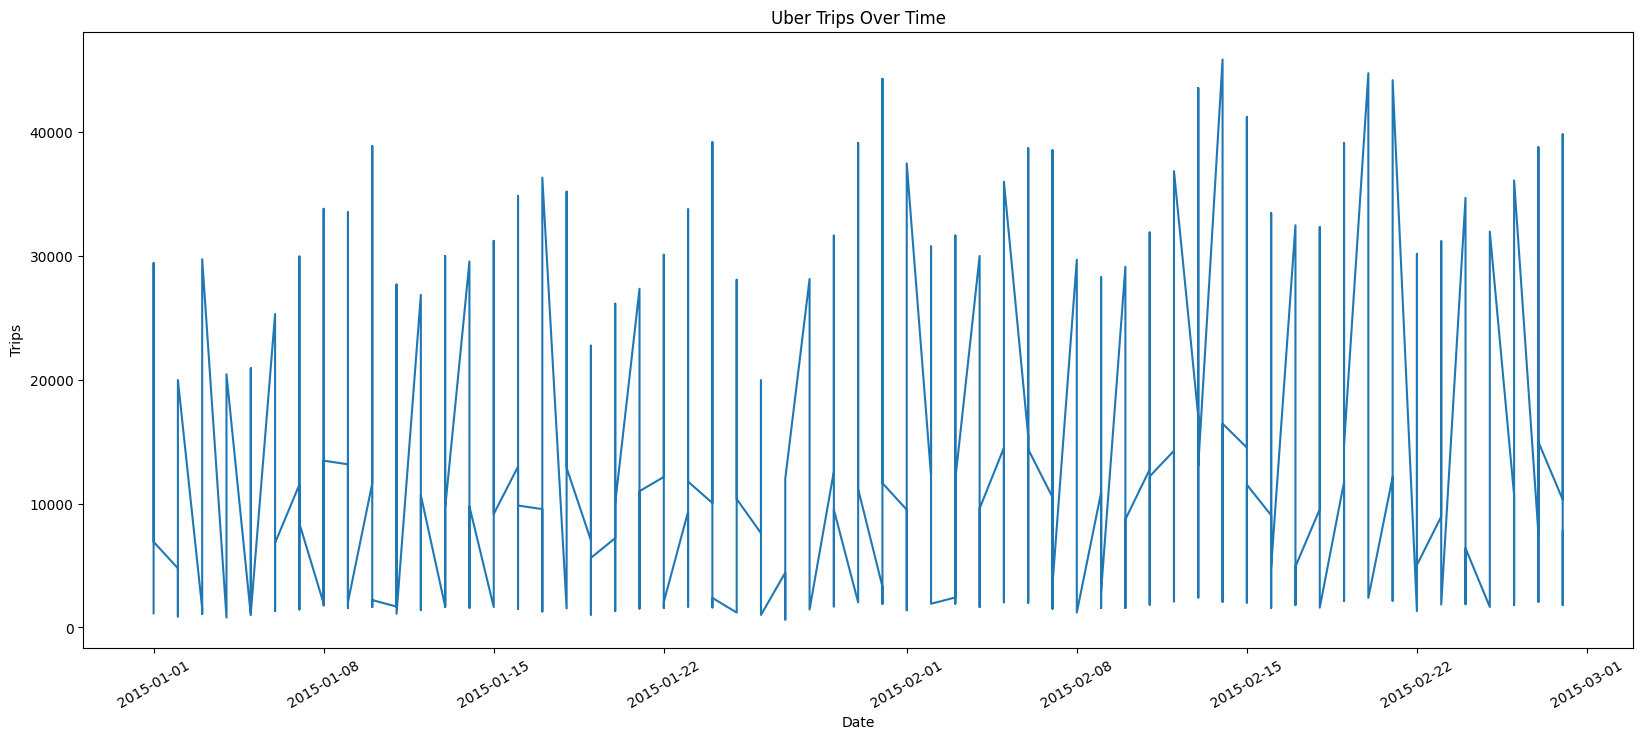

In [12]:
import matplotlib.pyplot as plt

plt.figure(figsize=(20, 8))

plt.plot(data.index, data['trips'])

plt.title("Uber Trips Over Time")
plt.xlabel("Date")
plt.ylabel("Trips")

plt.xticks(rotation=30)
plt.show()

In [8]:
print(data.columns)

Index(['dispatching_base_number', 'date', 'active_vehicles', 'trips', 'Day',
       'Month', 'DayOfWeek'],
      dtype='object')


In [9]:
data.set_index('date', inplace=True)

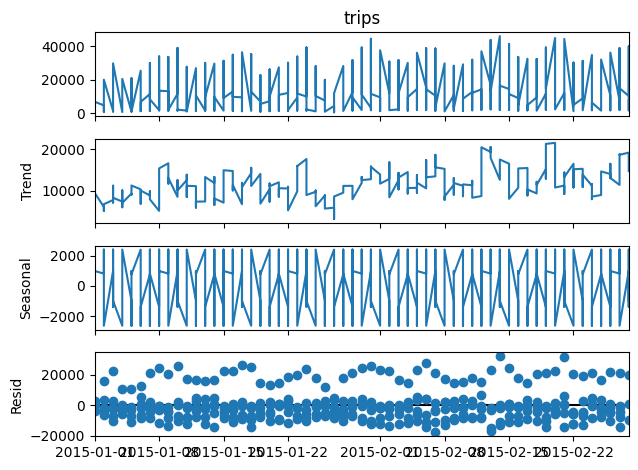

In [11]:
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import seasonal_decompose

result = seasonal_decompose(data['trips'], model='additive', period=7)

result.plot()
plt.show()

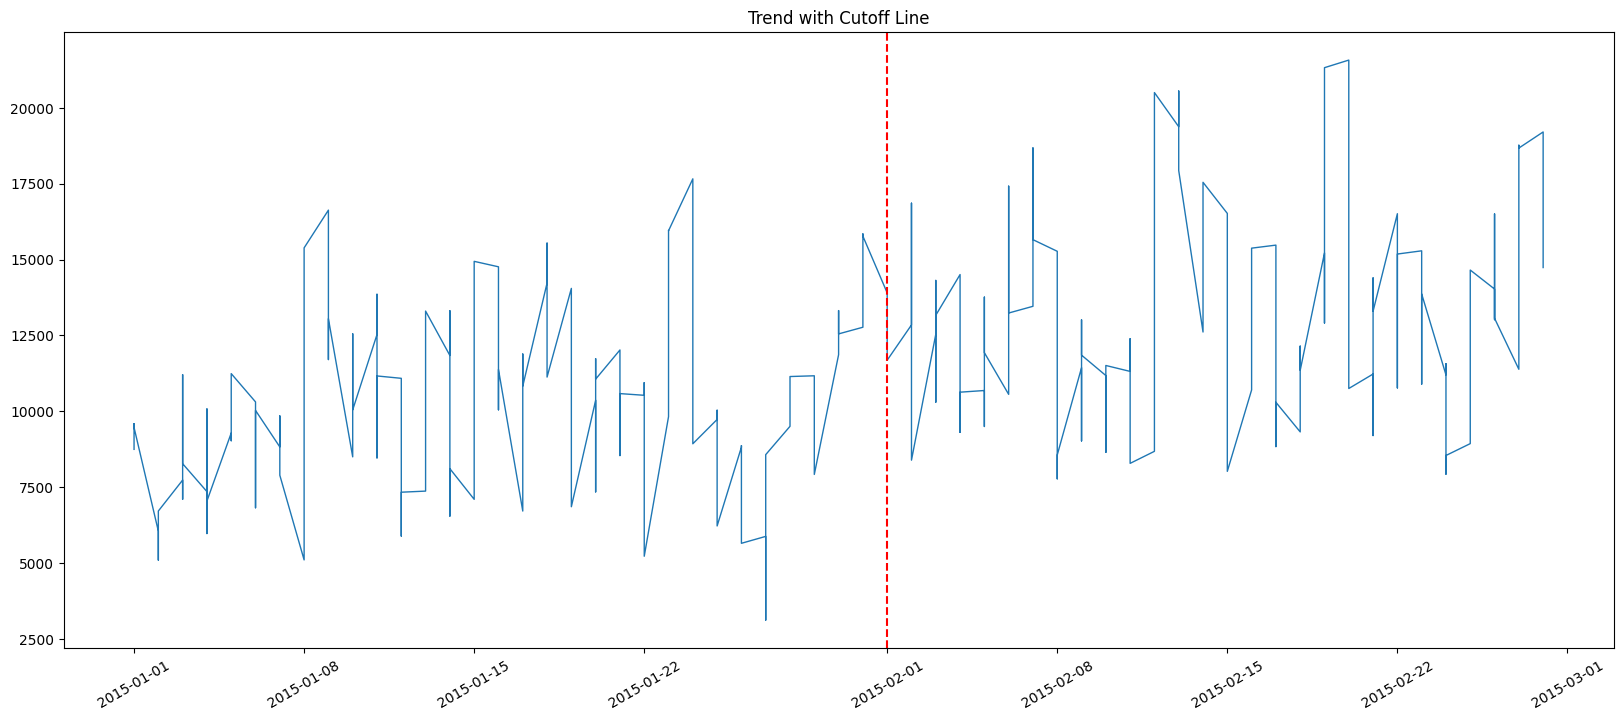

In [13]:

trend = result.trend

cutoff_date = '2015-02-01'

plt.figure(figsize=(20, 8))

plt.plot(trend, linewidth=1)

plt.axvline(x=pd.to_datetime(cutoff_date), color='red', linestyle='--')

plt.title("Trend with Cutoff Line")
plt.xticks(rotation=30)

plt.show()

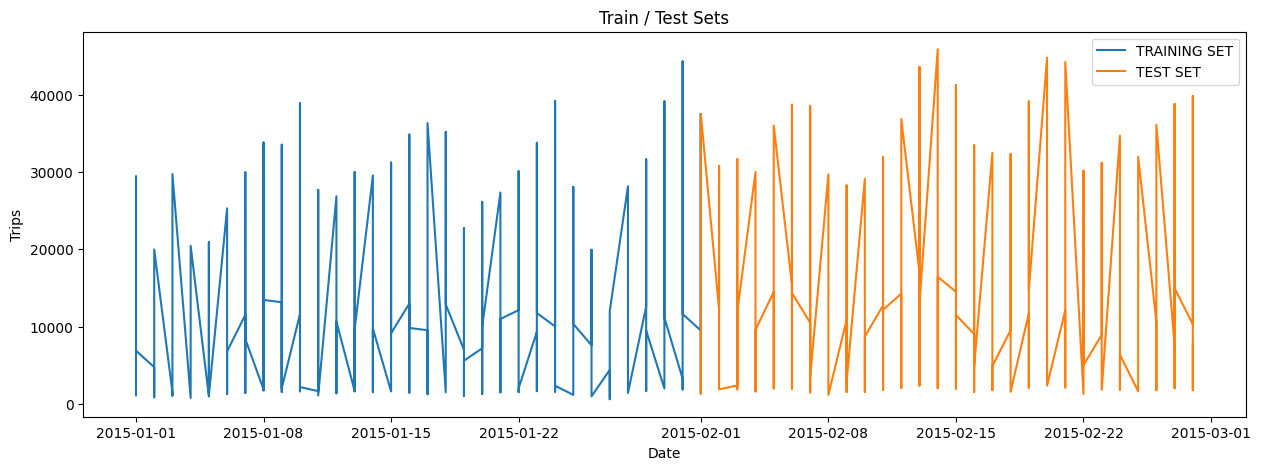

In [14]:

cutoff_date = '2015-02-01'

train = data.loc[:cutoff_date]
test = data.loc[cutoff_date:]

plt.figure(figsize=(15,5))

plt.plot(train.index, train['trips'], label='TRAINING SET')
plt.plot(test.index, test['trips'], label='TEST SET')

plt.title("Train / Test Sets")
plt.xlabel("Date")
plt.ylabel("Trips")

plt.legend()
plt.show()

In [16]:
import numpy as np
import xgboost as xgb
from sklearn.model_selection import GridSearchCV, TimeSeriesSplit
from sklearn.metrics import mean_absolute_percentage_error

X = np.arange(len(data)).reshape(-1,1)
y = data['trips'].values

split_index = len(train)

X_train, X_test = X[:split_index], X[split_index:]
y_train, y_test = y[:split_index], y[split_index:]

tscv = TimeSeriesSplit(n_splits=5)

param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [3, 6],
    'learning_rate': [0.01, 0.1]
}

model = xgb.XGBRegressor(objective='reg:squarederror')

grid = GridSearchCV(model, param_grid, cv=tscv,
                    scoring='neg_mean_absolute_percentage_error')

grid.fit(X_train, y_train)

print("Best Parameters:", grid.best_params_)

y_pred = grid.predict(X_test)

mape = mean_absolute_percentage_error(y_test, y_pred)
print("MAPE:", mape)

Best Parameters: {'learning_rate': 0.01, 'max_depth': 6, 'n_estimators': 100}
MAPE: 2.885650157928467


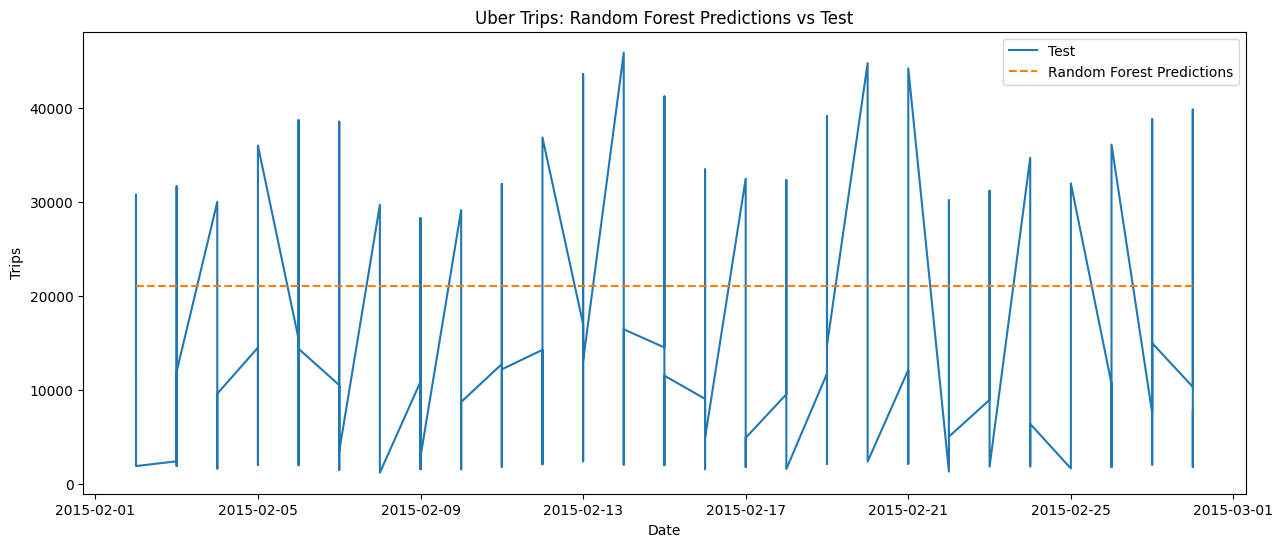

In [19]:

test_index = data.index[-len(y_test):]

plt.figure(figsize=(15,6))

plt.plot(test_index, y_test, label='Test')

plt.plot(test_index, y_pred, linestyle='--', label='Random Forest Predictions')

plt.xlabel("Date")
plt.ylabel("Trips")

plt.title("Uber Trips: Random Forest Predictions vs Test")

plt.legend()
plt.show()

In [20]:
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.model_selection import GridSearchCV

param_grid = {
    'n_estimators': [100, 200],
    'learning_rate': [0.01, 0.1],
    'max_depth': [3, 5]
}

gbr = GradientBoostingRegressor()

grid_gbr = GridSearchCV(gbr, param_grid, cv=3)

grid_gbr.fit(X_train, y_train)

print("Best Parameters:", grid_gbr.best_params_)

gbr_pred = grid_gbr.predict(X_test)

Best Parameters: {'learning_rate': 0.01, 'max_depth': 3, 'n_estimators': 100}


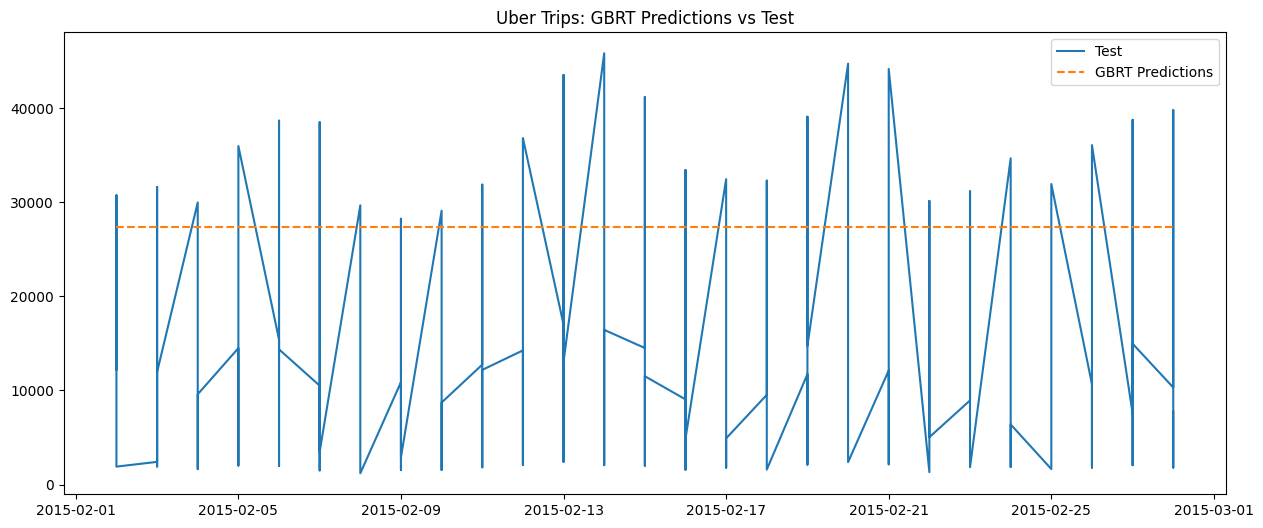

In [21]:
test_index = data.index[-len(y_test):]

plt.figure(figsize=(15,6))

plt.plot(test_index, y_test, label='Test')
plt.plot(test_index, gbr_pred, linestyle='--', label='GBRT Predictions')

plt.title("Uber Trips: GBRT Predictions vs Test")

plt.legend()
plt.show()

In [23]:
from sklearn.ensemble import RandomForestRegressor
rf_model = RandomForestRegressor()
rf_model.fit(X_train, y_train)
rf_pred = rf_model.predict(X_test)

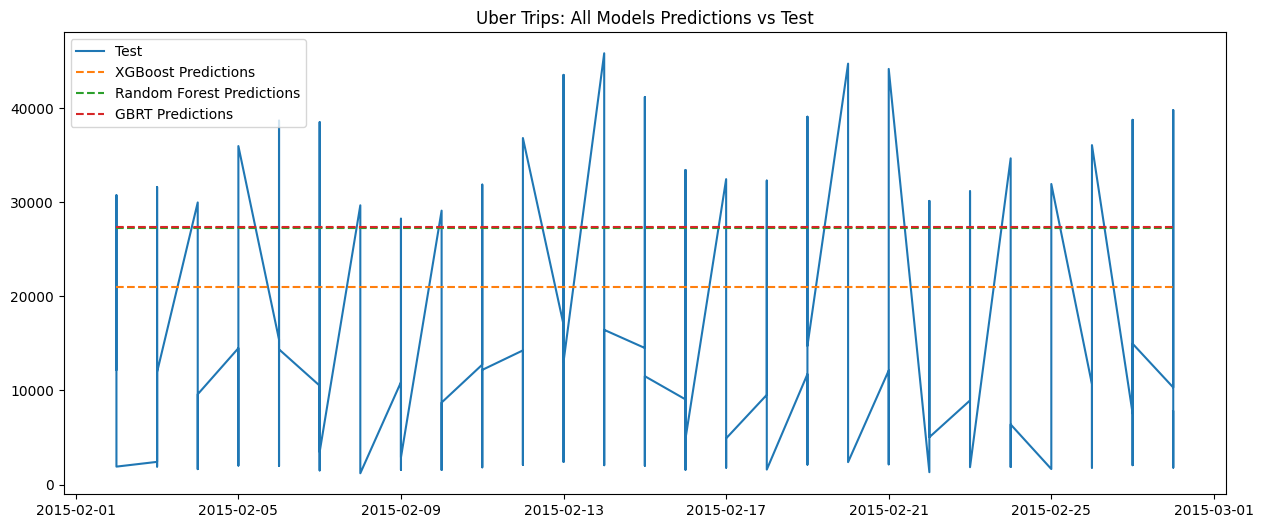

In [24]:
test_index = data.index[-len(y_test):]
plt.figure(figsize=(15,6))
plt.plot(test_index, y_test, label='Test')
plt.plot(test_index, y_pred, linestyle='--', label='XGBoost Predictions')
plt.plot(test_index, rf_pred, linestyle='--', label='Random Forest Predictions')
plt.plot(test_index, gbr_pred, linestyle='--', label='GBRT Predictions')
plt.title("Uber Trips: All Models Predictions vs Test")
plt.legend()
plt.show()

In [30]:

w1, w2, w3 = 0.4, 0.3, 0.3

ensemble_pred = (w1 * y_pred) + (w2 * rf_pred) + (w3 * gbr_pred)

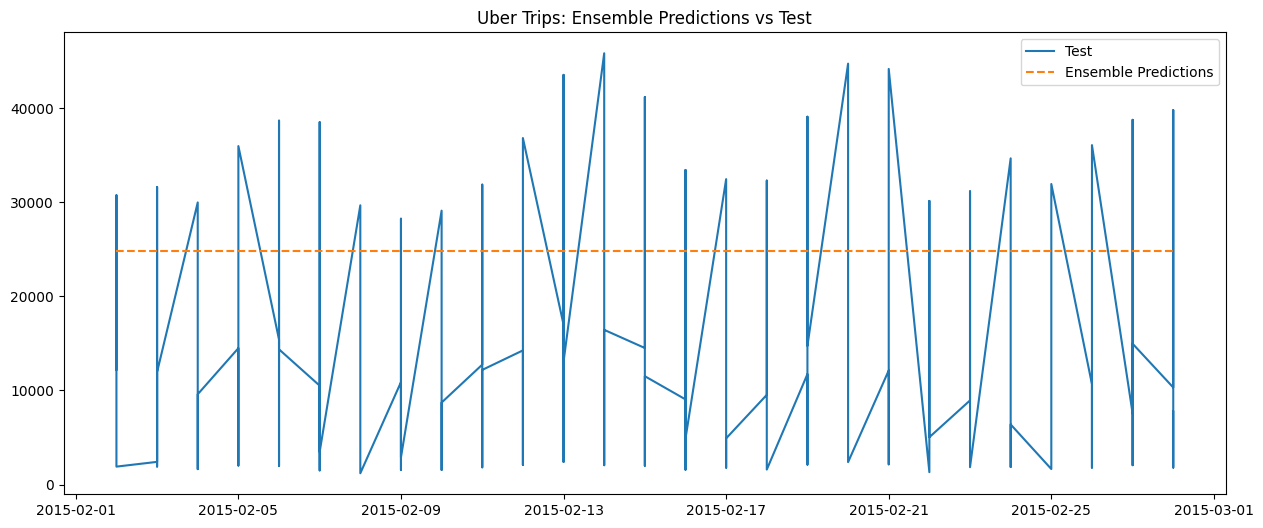

In [26]:
plt.figure(figsize=(15,6))
plt.plot(test_index, y_test, label='Test')
plt.plot(test_index, ensemble_pred, linestyle='--', label='Ensemble Predictions')
plt.title("Uber Trips: Ensemble Predictions vs Test")
plt.legend()
plt.show()

In [31]:
from sklearn.metrics import mean_absolute_percentage_error

xgb_mape = mean_absolute_percentage_error(y_test, y_pred)
rf_mape = mean_absolute_percentage_error(y_test, rf_pred)

gbr_mape = mean_absolute_percentage_error(y_test, gbr_pred)

ensemble_mape = mean_absolute_percentage_error(y_test, ensemble_pred)

print(f"XGBoost MAPE: {xgb_mape*100:.2f}%")
print(f"Random Forest MAPE: {rf_mape*100:.2f}%")
print(f"GBRT MAPE: {gbr_mape*100:.2f}%")
print(f"Ensemble MAPE: {ensemble_mape*100:.2f}%  ✅ BEST")

XGBoost MAPE: 288.57%
Random Forest MAPE: 394.77%
GBRT MAPE: 395.45%
Ensemble MAPE: 352.49%  ✅ BEST
